# EDA
Exploratory data analysis on NLP Disaster Tweets data set.

In [1]:
# Read necessary modules
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import os

In [45]:
os.chdir('/home/54b3e09d-d775-4c65-93b7-67c241d43466/5511_PR_week4')

In [140]:
# Read train and test set
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("The training set has {} observations".format(len(train_df)))
print("The test set has {} observations".format(len(test_df)))

The training set has 7613 observations
The test set has 3263 observations


In [22]:
train_df.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


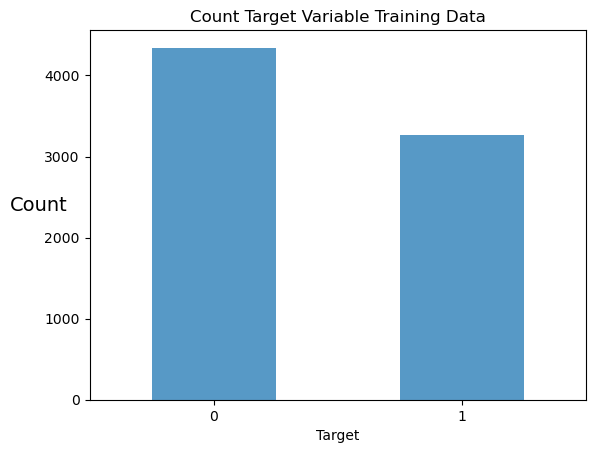

In [46]:
# Train data: Bar plot of target variable 
train_df.groupby('target')['target'].count().plot(kind= 'bar',alpha = 0.75)
plt.xticks(rotation=0)
plt.xlabel('Target')
plt.ylabel('Count', fontsize =14, rotation = 0)
plt.title('Count Target Variable Training Data')
#plt.show()
plt.savefig('Bar_target.jpeg')

In [51]:
# For plotting purposes put length of tweets in a separate list 

# Training data
len_tweets = []

for i in train_df.text:
    len_tweets.append(len(i))

# Test data 
len_tweets_test = []

for i in test_df.text:
    len_tweets_test.append(len(i))


[69, 38, 133, 65, 88]

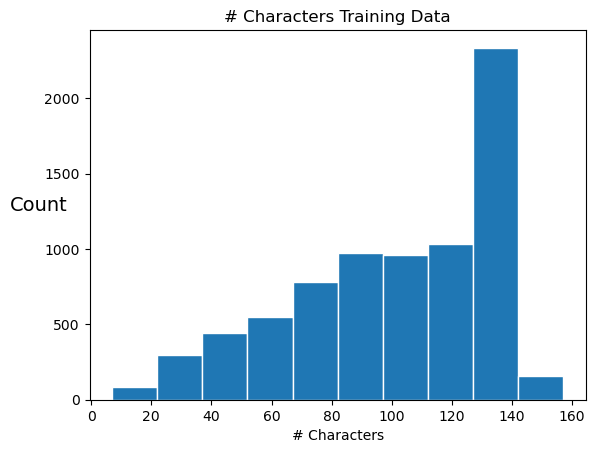

In [142]:
# Histogram of length of tweets training data
plt.hist(len_tweets, edgecolor='white')
plt.xlabel('# Characters')
plt.ylabel('Count', fontsize = 14, rotation = 0)
plt.title('# Characters Training Data')
#plt.show()
plt.savefig('train_length.jpeg')

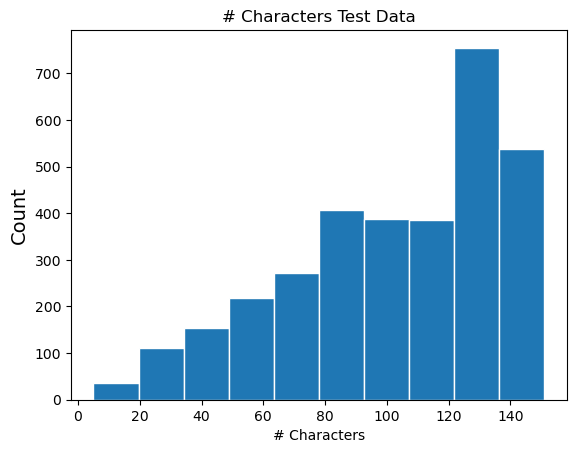

In [143]:
# Histogram of length of tweets test data
plt.hist(len_tweets_test, edgecolor='white')
plt.xlabel('# Characters')
plt.ylabel('Count', fontsize = 14)
plt.title('# Characters Test Data')
#plt.show()
plt.savefig('test_length.jpeg')

In [63]:
# Put the list len_tweets in a dataframe
d = {'len_tweet': len_tweets}
len_tweet_train = pd.DataFrame(d)

# Join train_df and len_tweet_train on index
train_len_df = pd.concat([train_df, len_tweet_train], axis=1, join="inner")

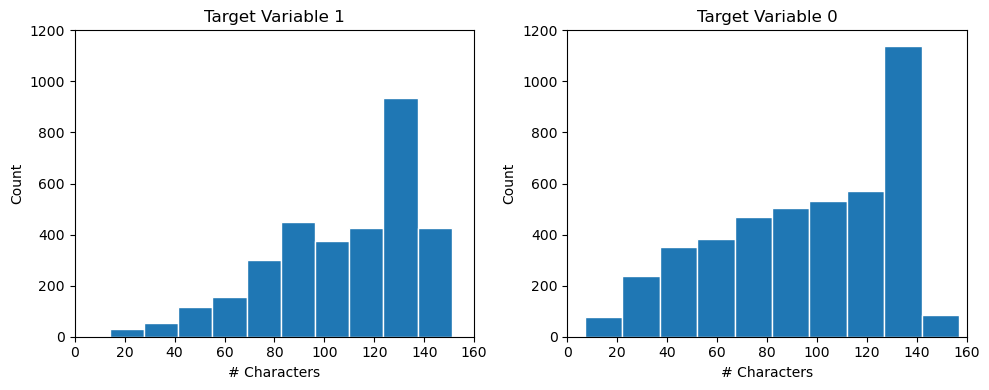

In [159]:
# Histogram of length of tweets training data, split on target variable
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(train_len_df[train_len_df.target == 1].loc[:,'len_tweet'], edgecolor='white')
ax[0].set_ylim(0,1200)
ax[0].set_xlim(0,160)
ax[0].set_ylabel('Count')
ax[0].set_xlabel('# Characters')
ax[0].set_title('Target Variable 1')

ax[1].hist(train_len_df[train_len_df.target == 0].loc[:,'len_tweet'], edgecolor='white')
ax[1].set_ylim(0,1200)
ax[1].set_xlim(0,160)
ax[1].set_ylabel('Count')
ax[1].set_xlabel('# Characters')
ax[1].set_title('Target Variable 0')

fig.tight_layout()
#plt.show()
plt.savefig('train_length_I.jpeg')

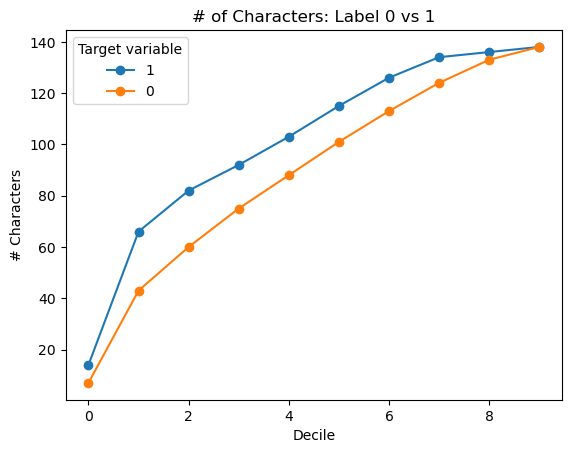

In [161]:
# Get the deciles of the number of characters for observations with target 0 and 1
decile_tar_one = np.percentile(train_len_df[train_len_df.target == 1].loc[:,'len_tweet'], np.arange(0, 100, 10))
decile_tar_zero = np.percentile(train_len_df[train_len_df.target == 0].loc[:,'len_tweet'], np.arange(0, 100, 10))

# Plot of deciles target variables 
plt.plot(decile_tar_one, 'o-', label = '1')
plt.plot(decile_tar_zero, 'o-', label = '0')
plt.xlabel('Decile')
plt.ylabel('# Characters')
plt.title('# of Characters: Label 0 vs 1')
plt.legend(title = 'Target variable')
#plt.show()
plt.savefig('Decile_plot.jpeg')